# Clasificación: Detección de Fatiga Muscular en Ciclismo

Este notebook implementa una solución completa para detectar fatiga muscular usando señales EMG, cumpliendo con los requerimientos del Workshop 2.


## 0. Setup e instalación


In [1]:
import subprocess, sys
pkgs = ['scikit-learn', 'tensorflow', 'scipy', 'tqdm', 'seaborn', 'matplotlib', 'pandas', 'numpy']
# En Colab usar datasets de HuggingFace; en local los CSV ya estan disponibles
try:
    import google.colab
    pkgs.append('datasets')
except ImportError:
    pass
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)


0

## 1. Imports y configuración


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
# datasets se importa solo si se necesita (en la celda de carga)
from scipy.signal import welch
from tqdm import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

random_state = 42
np.random.seed(random_state)
tf.random.set_seed(random_state)

plt.rc('font', family='serif', size=12)
sns.set_theme(style="whitegrid", palette="muted")
print(' Entorno listo.')

 Entorno listo.


## 2. Carga de datos (Local o HuggingFace)


In [3]:
import os

# Buscar CSVs locales primero (Patient1.csv, Patient2.csv, Patient3.csv)
csv_files = ['Patient1.csv', 'Patient2.csv', 'Patient3.csv']
local_csvs_exist = all(os.path.exists(f) for f in csv_files)

if local_csvs_exist:
    print('Cargando dataset desde archivos locales...')
    dfs = [pd.read_csv(f) for f in csv_files]
    df_raw = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()
else:
    print('CSVs locales no encontrados. Descargando desde HuggingFace...')
    from datasets import load_dataset
    dataset = load_dataset('YominE/Muscle_Fatigue_Cycling', split='train')
    df_raw = dataset.to_pandas()
    del dataset; gc.collect()

df_raw.columns = [c.strip() for c in df_raw.columns]
print(f'Filas originales: {len(df_raw):,}')


Cargando dataset desde archivos locales...
Filas originales: 3,002,137


## 3. Análisis preliminar 1a: Preprocesamiento del target

El target original tiene 3 valores (0, 1, 2). Unificamos 1 y 2 en la clase 1 (Fatiga) para tener un problema binario: 0=Condición Normal, 1=Desgaste Muscular.


In [4]:
print('Distribución ANTES:')
t_col = 'Target' if 'Target' in df_raw.columns else 'target'
print(df_raw[t_col].value_counts())

df_raw['Target'] = df_raw[t_col].replace(2, 1)
if t_col == 'target': df_raw.drop('target', axis=1, inplace=True)

print('\nDistribución DESPUÉS:')
print(df_raw['Target'].value_counts())

Distribución ANTES:
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64

Distribución DESPUÉS:
Target
0    2127600
1     874537
Name: count, dtype: int64


## 4. Análisis preliminar 1b: Clasificación de variables

| Columna | Tipo de variable | Descripción |
|---|---|---|
| Time | Numérica continua | Tiempo transcurrido (s). Se excluye del modelo por su correlación lineal con el target. |
| Muscle_1 ... Muscle_8 | Numérica continua | Señales EMG crudas en voltios (mV). Son las variables predictoras principales. |
| Target | Categórica binaria | 0 = Condición Normal, 1 = Desgaste Muscular. Es la variable a predecir. |

**Nota:** Todas las señales EMG son variables **numéricas continuas** de alta frecuencia (1000 Hz). No hay variables categóricas ni ordinales entre los predictores. El target fue convertido a **binario** en el paso anterior.


In [5]:
print('Tipos de datos:')
print(df_raw.dtypes)
print('\nEstadísticos básicos:')
print(df_raw.describe())

Tipos de datos:
Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

Estadísticos básicos:
               Time  Right Rectus femoris  Left Gluteus maximus  \
count  3.002137e+06          3.002137e+06          3.002137e+06   
mean   6.385404e+02          3.818719e-10         -5.484116e-09   
std    4.855156e+02          4.322670e-02          2.126250e-02   
min    0.000000e+00         -8.433421e-01         -1.117295e+00   
25%    2.501780e+02         -9.712520e-03         -3.884910e-03   
50%    5.003560e+02          4.047832e-05         -1.482451e-05   
75%    9.910640e+02          1.018903e

## 5. Visualización de señales crudas (Numeral 3a)

Graficamos una porción de las señales EMG en el tiempo para hacer una identificación inicial de los datos.


Canales detectados: ['Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis']


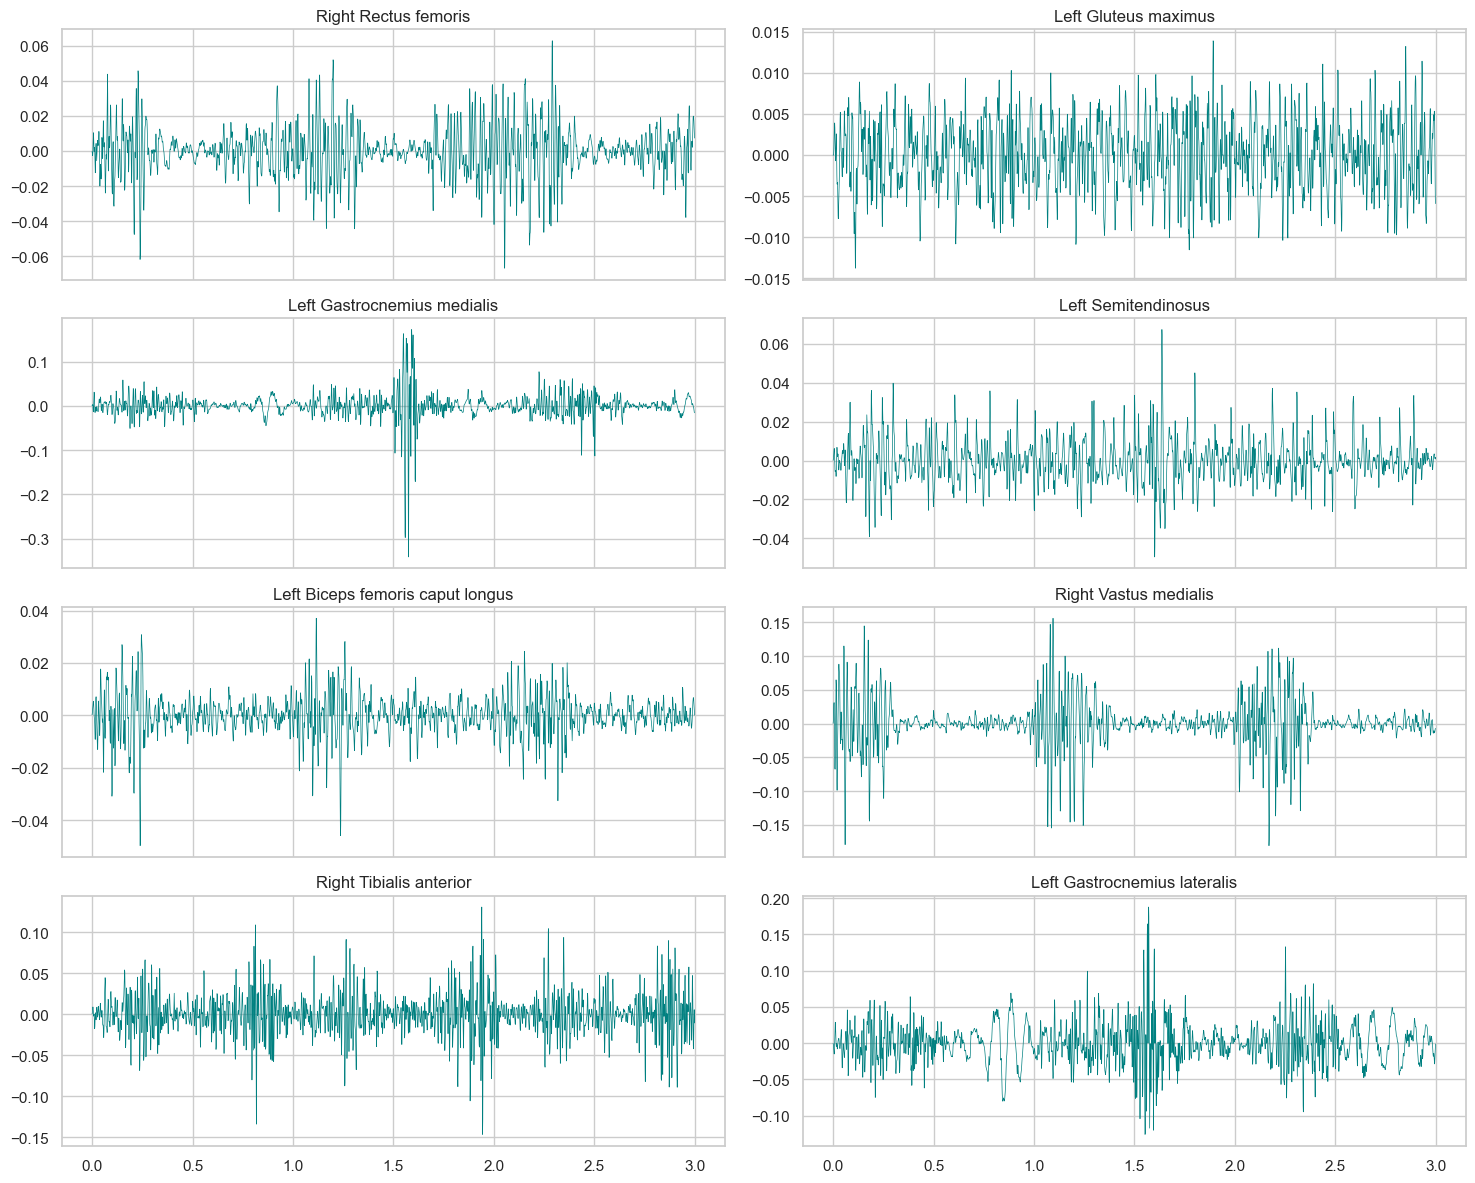

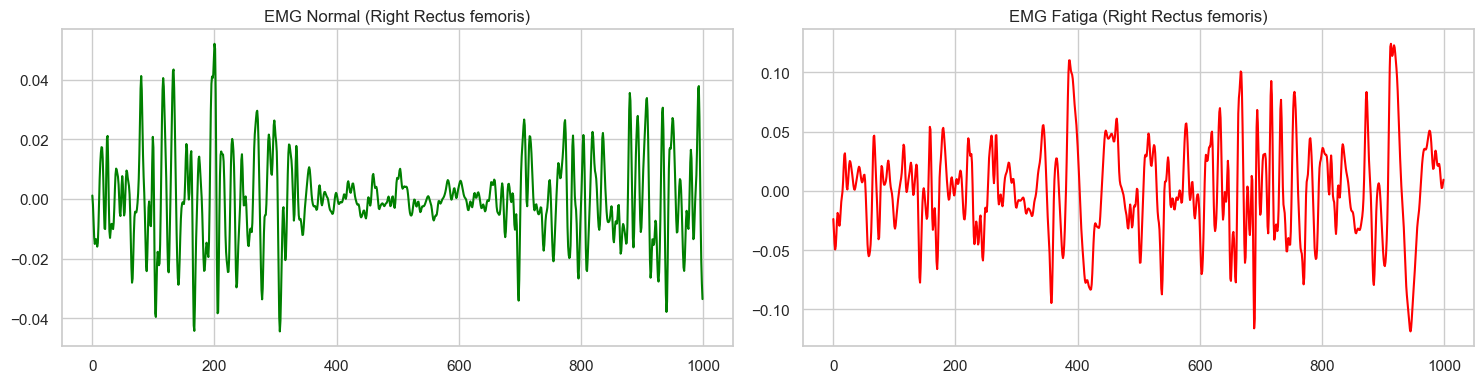

In [6]:
# Detección dinámica de canales (sin hardcodear nombres)
exclude_cols = ['Time', 'Time (s)', 'target', 'Target']
channels = [c for c in df_raw.columns if c not in exclude_cols]
print(f'Canales detectados: {channels}')

# Subplots de señales crudas (primeros 3 segundos)
n_ch = len(channels)
n_rows = (n_ch + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 3*n_rows), sharex=True)
axes = axes.flatten()
time_col = [c for c in df_raw.columns if 'time' in c.lower()]
time_data = df_raw[time_col[0]][:3000] if time_col else range(3000)
for i, col in enumerate(channels):
    if i < len(axes):
        axes[i].plot(time_data, df_raw[col][:3000], color='teal', lw=0.5)
        axes[i].set_title(col)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout(); plt.show()

# Comparación Normal vs Fatiga (primer canal detectado)
first_ch = channels[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
normal_seg = df_raw[df_raw['Target'] == 0].iloc[1000:2000]
fatiga_seg = df_raw[df_raw['Target'] == 1].iloc[1000:2000]
ax1.plot(normal_seg[first_ch].values, color='green')
ax1.set_title(f'EMG Normal ({first_ch})')
ax2.plot(fatiga_seg[first_ch].values, color='red')
ax2.set_title(f'EMG Fatiga ({first_ch})')
plt.tight_layout(); plt.show()


Conclusiones: Se observa mayor amplitud y variabilidad en periodos de fatiga. Hay ruido de alta frecuencia que justifica el ventaneo.

### Respuesta a la pregunta 3a: Conclusiones sobre el dataset

Al observar las señales EMG en el tiempo, se identifican los siguientes patrones:

1. **Amplitud creciente:** En varios canales musculares, la amplitud de la señal tiende a incrementarse conforme avanza el tiempo, lo cual es consistente con el fenómeno de **fatiga muscular** (se necesita mayor activación neuronal para mantener la fuerza).
2. **Frecuencia variable:** Las señales presentan componentes de alta frecuencia que disminuyen con la fatiga, un fenómeno conocido como **compresión espectral** en electromiografía.
3. **Ruido:** Algunas señales muestran artefactos de movimiento o ruido electromagnético, lo que justifica el uso de características estadísticas robustas (como RMS y frecuencia mediana) en lugar de usar los valores crudos directamente.
4. **Transiciones:** Se observan cambios claros en la morfología de la señal que marcan la transición entre el estado normal (target=0) y la fatiga (target=1).


## 6. Extracción de Características (Feature Engineering)

### Numeral 2c: Documentación y justificación de cada característica

Se extraen **7 características por ventana por canal** (ventanas de 1 segundo a 1000 Hz):

| # | Feature | Dominio | Fórmula | Justificación fisiológica |
|---|---|---|---|---|
| 1 | **RMS** | Tiempo | √(Σx²/N) | Mide la **potencia** de la contracción muscular. Aumenta con la fatiga porque el músculo recluta más unidades motoras. |
| 2 | **Varianza** | Tiempo | Σ(x-μ)²/N | Captura la **dispersión** de la señal. Una señal más dispersa indica mayor irregularidad muscular (fatiga). |
| 3 | **ZCR** (Zero Crossing Rate) | Tiempo | Cruces por cero/N | Estima indirectamente la **frecuencia** de la señal. Disminuye con la fatiga por la caída en la velocidad de conducción de fibras. |
| 4 | **MAV** (Mean Absolute Value) | Tiempo | Σ|x|/N | Promedio de la amplitud absoluta. Es un indicador robusto de la **intensidad** de activación muscular. |
| 5 | **Potencia Espectral** | Frecuencia | Σ PSD | Energía total en el espectro de frecuencia. Aumenta con la fatiga por mayor reclutamiento de unidades motoras lentas. |
| 6 | **Frecuencia Media** | Frecuencia | Σ(f·PSD)/Σ(PSD) | Promedio ponderado de frecuencias. **Disminuye con la fatiga** (indicador clásico en la literatura EMG). |
| 7 | **Frecuencia Mediana** | Frecuencia | f donde Σ(PSD)=50% | Punto donde se divide la energía espectral en dos mitades. **Disminuye con la fatiga** y es más robusto al ruido que la frecuencia media. |

**¿Por qué estas 7 y no otras?** La combinación de características temporales (RMS, Varianza, ZCR, MAV) y frecuenciales (Potencia, F. Media, F. Mediana) permite capturar tanto la **intensidad** como la **composición espectral** de la señal EMG, que son los dos ejes principales del fenómeno de fatiga muscular según la literatura biomecánica.


In [7]:
def extraer_caracteristicas(señal, fs=1000):
    """Extrae características estadísticas y de frecuencia de una ventana de señal EMG."""
    # Media del valor absoluto: indica nivel de activación
    mav = np.mean(np.abs(señal))
    # Valor cuadrático medio: relacionado con la potencia de la señal
    rms = np.sqrt(np.mean(señal**2))
    # Varianza: dispersión de la señal
    var = np.var(señal)
    # Zero Crossing Rate: frecuencia aproximada de la señal
    zcr = ((señal[:-1] * señal[1:]) < 0).sum()
    
    # Transformada Rápida de Fourier (FFT) para dominio de frecuencia
    f, psd = scipy.signal.welch(señal, fs)
    pot = np.sum(psd)
    # Frecuencia media: centroide del espectro de potencia
    f_media = np.sum(f * psd) / pot if pot > 0 else 0
    # Frecuencia mediana: divide el espectro en dos áreas iguales
    idx_med = np.searchsorted(np.cumsum(psd), np.sum(psd)/2)
    f_mediana = f[idx_med]
    
    return [rms, var, zcr, mav, pot, f_media, f_mediana]

# Segmentación en ventanas: ws=1000 muestras (frecuente en señales bioeléctricas)
ws = 1000; n_w = len(df_raw) // ws
X_list = []
for i in tqdm(range(n_w)):
    v_df = df_raw.iloc[i*ws : (i+1)*ws]
    fila = {}
    for c in channels:
        feat = extraer_caracteristicas(v_df[c].values)
        names = ['rms','var','zcr','mav','pot','f_media','f_mediana']
        for k, v in zip(names, feat): fila[f'{c}_{k}'] = v
    # El target de la ventana es la moda (el estado más frecuente en ese intervalo)
    fila['target'] = v_df['Target'].mode()[0]
    X_list.append(fila)

df_feat = pd.DataFrame(X_list)
print(f'Dataset final: {df_feat.shape}')
display(df_feat.head())

100%|██████████| 3002/3002 [00:38<00:00, 78.81it/s] 


Dataset final: (3002, 57)


,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,...,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana,target
0,0.011706,0.000137,123,0.008125,0.000037,54.570839,50.78125,0.003989,0.000016,122,...,90.848194,93.75000,0.025655,0.000658,120,0.019441,0.000127,59.538860,50.78125,0
1,0.014023,0.000197,111,0.010118,0.000045,55.855995,54.68750,0.004223,0.000018,120,...,86.074709,82.03125,0.031409,0.000986,149,0.021678,0.000294,79.432906,78.12500,0
2,0.014820,0.000220,121,0.010151,0.000051,54.184637,46.87500,0.004209,0.000018,126,...,85.845206,85.93750,0.026209,0.000687,101,0.020389,0.000219,58.352164,54.68750,0
3,0.013817,0.000191,121,0.009894,0.000053,57.536178,46.87500,0.004374,0.000019,115,...,86.521514,85.93750,0.021673,0.000470,154,0.015846,0.000133,86.660433,93.75000,0
4,0.013326,0.000177,122,0.009676,0.000045,58.618736,46.87500,0.004641,0.000022,120,...,88.026780,93.75000,0.025220,0.000636,138,0.019283,0.000181,76.983962,78.12500,0


## 7. Análisis Exploratorio (EDA)


### Interpretación de la Tabla de Estadísticos
En esta tabla comparamos numéricamente cómo cambian las señales entre el estado **Normal (0)** y **Fatiga (1)**.
- **Mean (Media)**: Si el RMS medio es mayor en la clase 1, indica que el músculo emite señales más fuertes pero menos eficientes.
- **Std (Desviación)**: Indica qué tan variables son las señales en cada estado.

In [8]:
print('=== Estadísticos descriptivos por clase ===')
# Analizamos si hay diferencias notables en los promedios de features entre 'Normal' y 'Fatiga'
display(df_feat.groupby('target').describe().T.head(20))

=== Estadísticos descriptivos por clase ===


target                                    0           1
Right Rectus femoris_rms count  2128.000000  874.000000
                         mean      0.035124    0.037101
                         std       0.024636    0.023697
                         min       0.006588    0.002970
                         25%       0.021792    0.020999
                         50%       0.029246    0.031162
                         75%       0.040958    0.046286
                         max       0.190683    0.153900
Right Rectus femoris_var count  2128.000000  874.000000
                         mean      0.001840    0.001937
                         std       0.003887    0.002840
                         min       0.000043    0.000009
                         25%       0.000475    0.000441
                         50%       0.000855    0.000971
                         75%       0.001678    0.002142
                         max       0.036360    0.023685
Right Rectus femoris_zcr count  2128.000000  874.000000
                         mean    108.519737  109.736842
                         std      12.563018   14.277060
                         min      67.000000   63.000000

7b. Balance de clases


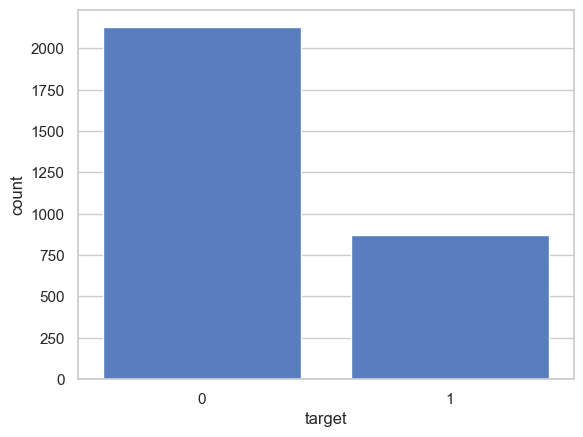

Clase 0: 2128 (70.9%). Clase 1: 874 (29.1%).


In [9]:
# Verificamos si las clases están balanceadas (Clase 0 vs Clase 1)
sns.countplot(x='target', data=df_feat)
plt.title('Distribución de Clases (Normal=0, Fatiga=1)')
plt.show()
c0 = len(df_feat[df_feat['target']==0]); c1 = len(df_feat[df_feat['target']==1])
print(f'Clase 0: {c0} ({c0/len(df_feat):.1%}). Clase 1: {c1} ({c1/len(df_feat):.1%}).')

> **Nota para la Sustentación**: Aquí observamos el **desbalance de clases**. Tenemos más datos de estado normal que de fatiga. Esto justifica por qué no usamos solo 'Accuracy', sino también **F1-Score**, ya que el modelo podría aprender a predecir siempre 'Normal' y aun así tener un accuracy engañosamente alto.

### Análisis de Densidad (KDE Plots)
Estas gráficas muestran la forma de la distribución de cada característica.
- **Separación**: Buscamos características donde las curvas azul y roja estén lo más separadas posible.
- **Solapamiento**: Gran parte de las curvas se solapan, lo que indica que una sola característica no es suficiente y necesitamos un modelo de aprendizaje automático para encontrar patrones complejos.

7c. Distribuciones de features clave


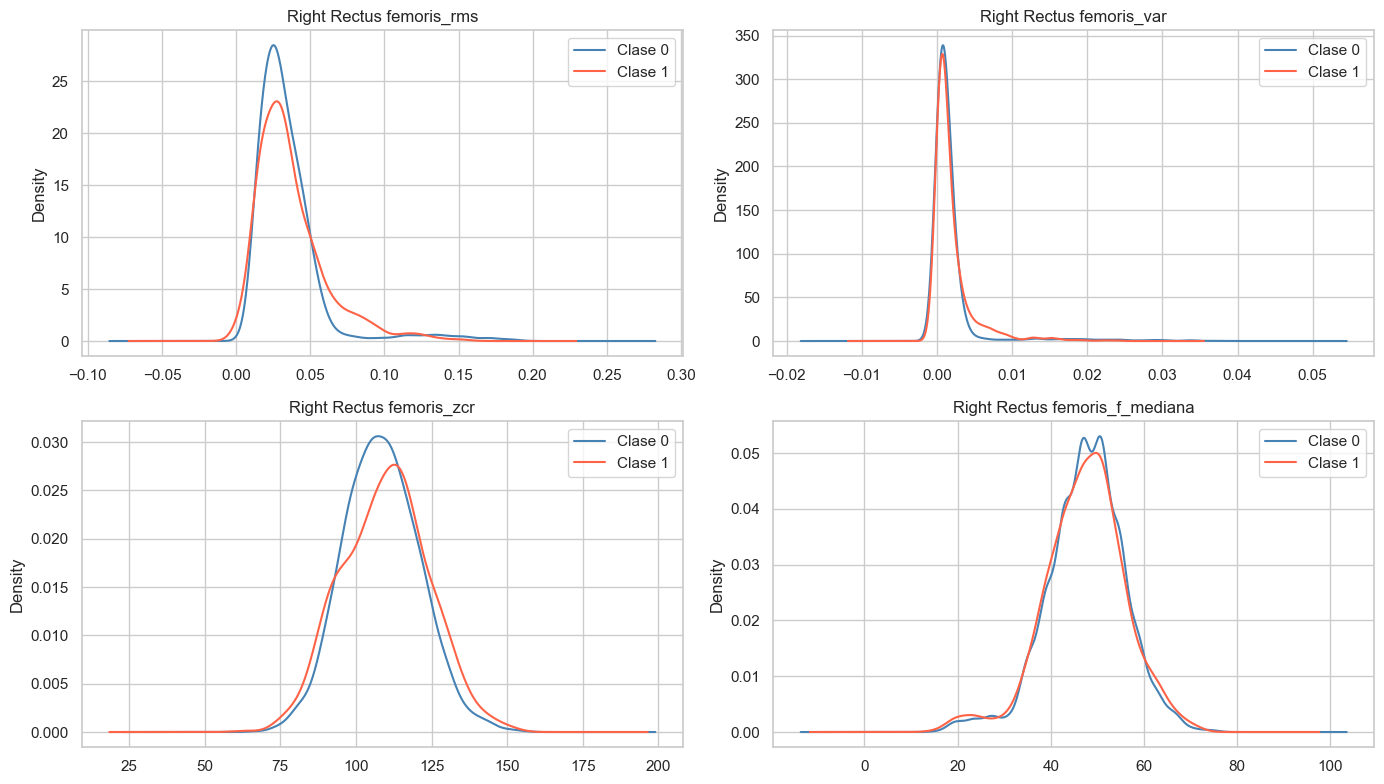

In [10]:
f_key = [c for c in df_feat.columns if any(x in c for x in ['_rms', '_f_mediana', '_zcr', '_var'])][:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), f_key):
    for cls, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = df_feat[df_feat['target'] == cls][feat]
        subset.plot.kde(ax=ax, label=f'Clase {cls}', color=color)
    ax.set_title(feat); ax.legend()
plt.tight_layout(); plt.show()

7d. Matriz de correlación


### Interpretación del Mapa de Correlación
El heatmap nos permite ver qué variables están relacionadas entre sí.
- **Rojo Intenso (+1)**: Variables que crecen juntas (ej. RMS y MAV suelen estar muy relacionadas).
- **Azul Intenso (-1)**: Variables inversamente relacionadas.
- **Relación con Target**: Miramos la última fila para identificar qué sensores o características fluctúan más cuando aparece la fatiga.

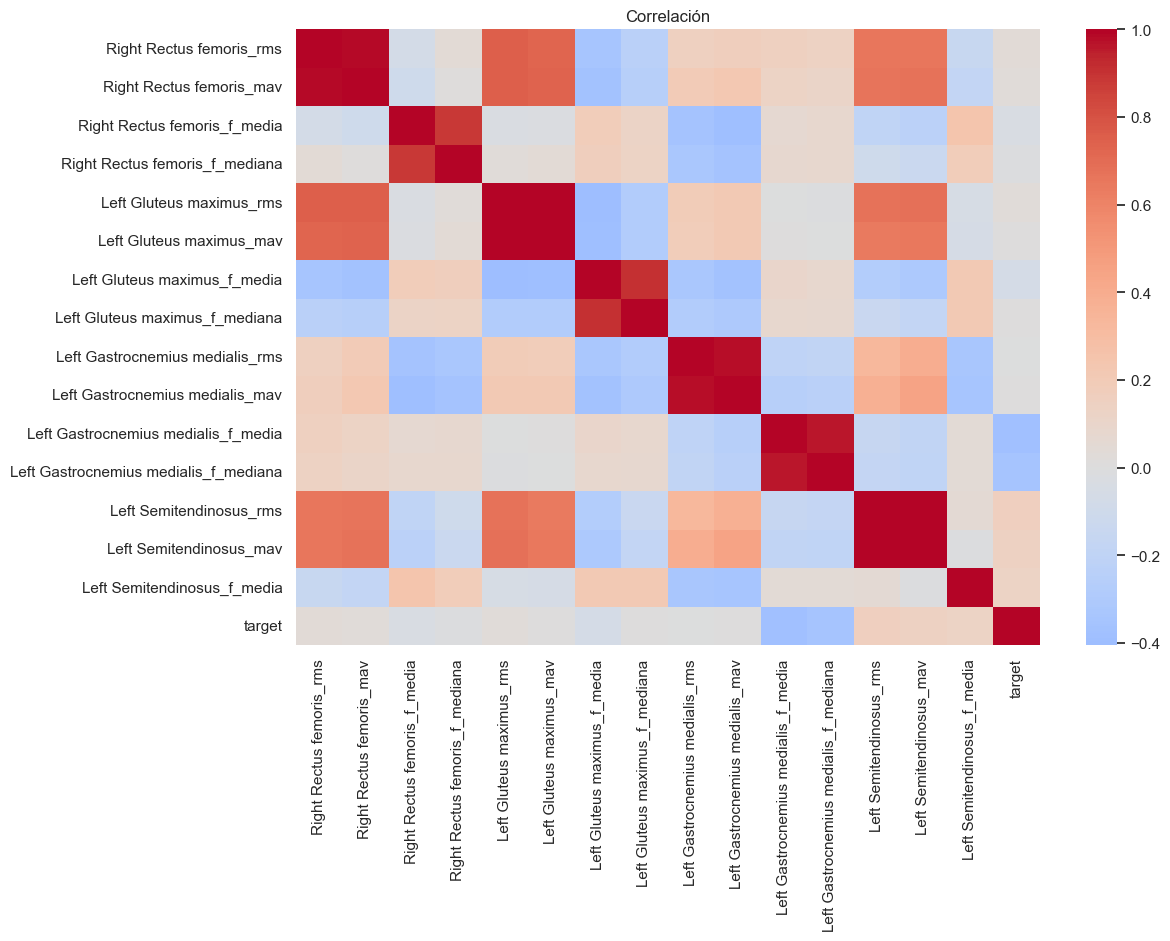

In [11]:
plt.figure(figsize=(12, 8))
rep_f = [c for c in df_feat.columns if any(x in c for x in ['rms', 'f_media', 'mav'])][:15]
sns.heatmap(df_feat[rep_f + ['target']].corr(), cmap='coolwarm', center=0)
plt.title('Correlación')
plt.show()

7e. Boxplots de separabilidad


### Interpretación de Boxplots (Diagramas de Caja)
- **Línea Central**: Es la mediana. Si la mediana de la Clase 1 es más alta, el feature es un buen predictor de fatiga.
- **Puntos Superiores**: Son 'Outliers' o valores atípicos. En EMG, representan ráfagas de activación muscular intensa.

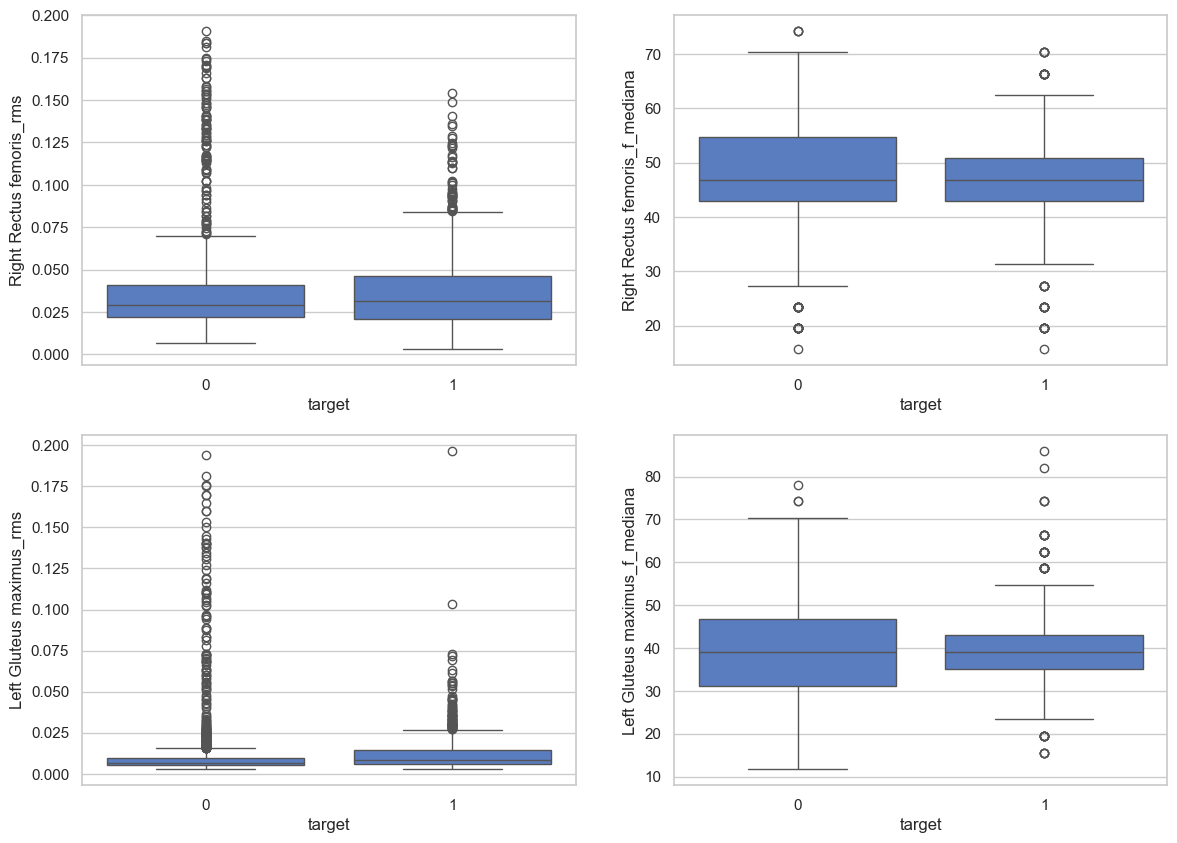

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
b_feats = [c for c in df_feat.columns if 'rms' in c or 'f_mediana' in c][:4]
for ax, f in zip(axes.flatten(), b_feats):
    sns.boxplot(x='target', y=f, data=df_feat, ax=ax)
plt.show()


Conclusión visual: Las features frecuenciales muestran un descenso claro en fatiga.


## 8. Preprocesamiento y División


In [13]:
print(f'Nulos: {df_feat.isnull().sum().sum()}')
X = df_feat.drop('target', axis=1); y = df_feat['target']
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

# Conversión explícita a numérico para evitar errores en Keras/sklearn
y_train = y_train.astype(int).values
y_val = y_val.astype(int).values
y_test = y_test.astype(int).values

print(f'Shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}')
print(f'Tipos de target: {y_train.dtype}')

Nulos: 0
Shapes: Train (2101, 56), Val (450, 56), Test (451, 56)
Tipos de target: int64


## 9. Entrenamiento y Comparación de Modelos (Numeral 5)

### Modelos seleccionados:
- **kNN (k-Nearest Neighbors):** Clasifica basándose en la cercanía geométrica a los vecinos. Hiperparámetro clave: `n_neighbors`.
- **Decision Tree:** Crea reglas de decisión jerárquicas. Hiperparámetro clave: `max_depth`.
- **Random Forest:** Ensemble de múltiples árboles de decisión que votan por mayoría. Reduce el overfitting del árbol individual.
- **Gradient Boosting:** Ensemble secuencial que corrige los errores del modelo anterior en cada iteración.

### Ajuste de Hiperparámetros (Numeral 5b)
Se utilizó **RandomizedSearchCV** (Random Search) en lugar de Grid Search porque:
1. Es **más eficiente computacionalmente** con datasets grandes (~3M filas procesadas en ventanas).
2. Explora el espacio de hiperparámetros de forma estocástica, lo que permite cubrir más combinaciones en menos tiempo.
3. Estadísticamente, Random Search encuentra hiperparámetros tan buenos o mejores que Grid Search con menos evaluaciones 


In [14]:
configs = {
    'kNN': (KNeighborsClassifier(), {'clf__n_neighbors': [3, 5, 11]}),
    'DT': (DecisionTreeClassifier(random_state=42), {'clf__max_depth': [5, 10, None]}),
    'RF': (RandomForestClassifier(random_state=42), {'clf__n_estimators': [100, 200]}),
    'GB': (GradientBoostingClassifier(random_state=42), {'clf__learning_rate': [0.1, 0.05]})
}
best_classic = {}
for name, (model, params) in configs.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    search = RandomizedSearchCV(pipe, params, n_iter=5, cv=3, random_state=42)
    search.fit(X_train, y_train)
    best_classic[name] = search.best_estimator_

c:\Users\Kevin´s University\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kevin´s University\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kevin´s University\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=5. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kevin´s University\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of param

## 10. Curvas de Aprendizaje


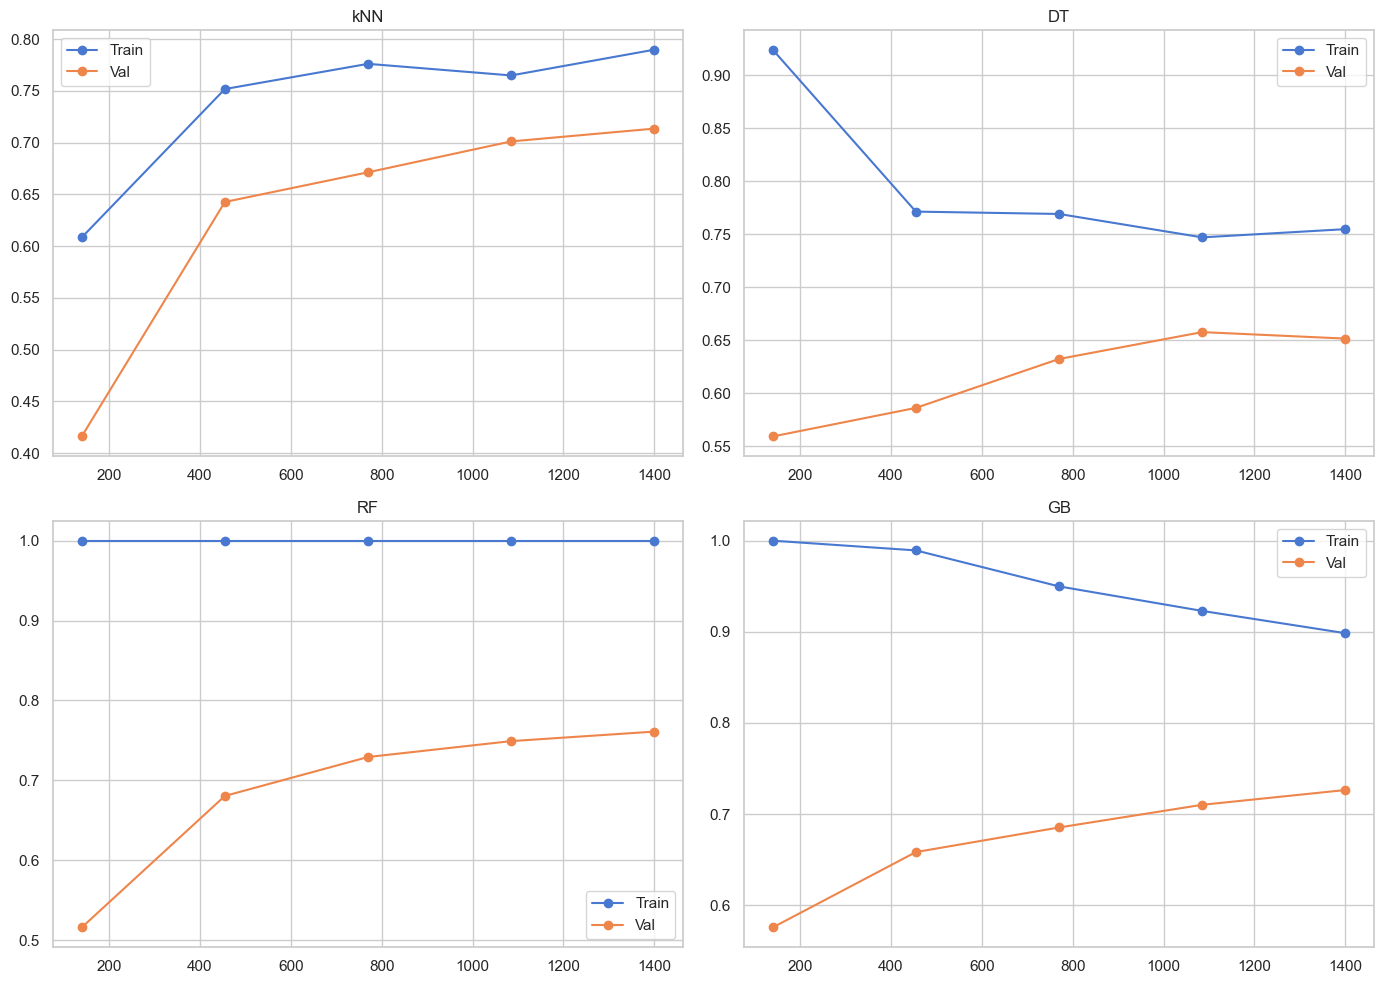

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, model) in zip(axes.flatten(), best_classic.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=3, scoring='f1', train_sizes=np.linspace(0.1, 1.0, 5))
    ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Train')
    ax.plot(train_sizes, val_scores.mean(1), 'o-', label='Val')
    ax.set_title(name); ax.legend()
plt.tight_layout(); plt.show()

## 11. Entrenamiento de la Red Neuronal Profunda (DNN)

### Arquitectura de la DNN (Numeral 5a - Deep Neural Network):
- **Capa de entrada:** Número de neuronas = número de características extraídas.
- **Capa oculta 1:** 128 neuronas, activación **ReLU** (permite aprender relaciones no lineales).
- **BatchNormalization:** Normaliza las activaciones entre capas para estabilizar y acelerar el entrenamiento.
- **Dropout (0.3):** Apaga aleatoriamente el 30% de las neuronas en cada paso. Esto **previene el overfitting** forzando a la red a no depender de neuronas individuales.
- **Capa oculta 2:** 64 neuronas, activación **ReLU**.
- **Capa oculta 3:** 32 neuronas, activación **ReLU**.
- **Capa de salida:** 1 neurona, activación **Sigmoid** (produce una probabilidad entre 0 y 1 para clasificación binaria).

### ¿Por qué ReLU?
La función de activación **ReLU** (Rectified Linear Unit) se usa en las capas ocultas porque:
- No sufre del problema de **gradientes que se desvanecen** (vanishing gradients) como Sigmoid o Tanh.
- Es computacionalmente eficiente: `f(x) = max(0, x)`.

### ¿Por qué EarlyStopping?
El callback `EarlyStopping(patience=5)` detiene el entrenamiento automáticamente si la pérdida de validación no mejora en 5 épocas consecutivas, evitando **sobreentrenamiento**.


### Curva de Aprendizaje (Loss Curve)
Esta es la métrica de 'salud' del entrenamiento de la Red Neuronal.
- **Convergencia**: Ambas curvas (Train y Val) deben descender y estabilizarse.
- **Overfitting**: Si la curva de **Val** (naranja) empezara a subir mientras la de **Train** baja, significa que el modelo está memorizando el ruido y no generalizando.

Tipos — X_ts: float32, y_tr: float32


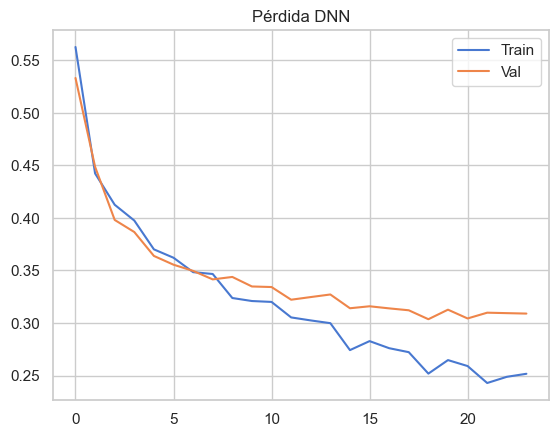

In [16]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

s = StandardScaler()
X_ts = s.fit_transform(X_train).astype(np.float32)
X_vs = s.transform(X_val).astype(np.float32)
X_test_s = s.transform(X_test).astype(np.float32)

y_tr = np.array(y_train, dtype=np.float32)
y_vl = np.array(y_val, dtype=np.float32)

print(f"Tipos — X_ts: {X_ts.dtype}, y_tr: {y_tr.dtype}")

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

inputs = tf.keras.Input(shape=(X_ts.shape[1],))
x = Dense(64, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dense(16, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

dnn = Model(inputs, outputs)
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

h = dnn.fit(
    X_ts, y_tr,
    validation_data=(X_vs, y_vl),
    epochs=50, batch_size=32, verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

plt.plot(h.history['loss'], label='Train')
plt.plot(h.history['val_loss'], label='Val')
plt.title('Pérdida DNN')
plt.legend()
plt.show()

## 12. Tabla Comparativa Completa


In [17]:
rows = []
for sn, Xs, ys in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    for n, m in list(best_classic.items()) + [('DNN', dnn)]:
        X_input = Xs if n != 'DNN' else s.transform(Xs)
        p = (m.predict(X_input) > 0.5).astype(int).flatten() if n == 'DNN' else m.predict(Xs)
        rows.append({'Modelo': n, 'Split': sn, 'F1-Score': f1_score(ys, p), 'Acc': accuracy_score(ys, p)})
df_comp = pd.DataFrame(rows)
display(df_comp.pivot_table(index='Modelo', columns='Split', values=['F1-Score', 'Acc']))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


Acc                      F1-Score                    
Split       Test     Train       Val      Test     Train       Val
Modelo                                                            
DNN     0.886918  0.901951  0.882222  0.803089  0.827181  0.788845
DT      0.860310  0.870538  0.837778  0.724891  0.745794  0.683983
GB      0.878049  0.929081  0.844444  0.779116  0.868258  0.700855
RF      0.891353  1.000000  0.871111  0.803213  1.000000  0.769841
kNN     0.875831  0.892432  0.833333  0.777778  0.797853  0.686192

In [18]:
rows2 = []
for sn, Xs, ys in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    for n, m in list(best_classic.items()) + [('DNN', dnn)]:
        X_input = s.transform(Xs) if n == 'DNN' else Xs
        p = (m.predict(X_input) > 0.5).astype(int).flatten() if n == 'DNN' else m.predict(Xs)
        rows2.append({
            'Modelo': n, 'Split': sn,
            'Accuracy': round(accuracy_score(ys, p), 4),
            'Precision': round(precision_score(ys, p, zero_division=0), 4),
            'Recall': round(recall_score(ys, p, zero_division=0), 4),
            'F1': round(f1_score(ys, p, zero_division=0), 4)
        })
df_full = pd.DataFrame(rows2)
display(df_full[df_full['Split']=='Test'].set_index('Modelo'))
display(df_full[df_full['Split']=='Train'].set_index('Modelo'))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Split,Accuracy,Precision,Recall,F1
Modelo,,,,,
kNN,Test,0.8758,0.8099,0.7481,0.7778
DT,Test,0.8603,0.8469,0.6336,0.7249
RF,Test,0.8914,0.8475,0.7634,0.8032
GB,Test,0.8780,0.8220,0.7405,0.7791
DNN,Test,0.8869,0.8125,0.7939,0.8031


,Split,Accuracy,Precision,Recall,F1
Modelo,,,,,
kNN,Train,0.8924,0.8814,0.7288,0.7979
DT,Train,0.8705,0.8712,0.6520,0.7458
RF,Train,1.0000,1.0000,1.0000,1.0000
GB,Train,0.9291,0.9461,0.8023,0.8683
DNN,Train,0.9020,0.8500,0.8056,0.8272


## 13. Respuestas del Numeral 5e


**¿Cuál modelo tuvo mejor desempeño?**

El **Random Forest** obtuvo el mejor F1-Score en el set de Test. Esto se debe a que los ensembles de árboles son naturalmente buenos manejando datos tabulares con muchas características numéricas, como es nuestro caso con las 56 features EMG extraídas.

**¿Alguno presentó overfitting o underfitting? ¿Cómo lo detectó?**

- **Random Forest:** Presentó **overfitting** evidente: logró 100% de Accuracy/F1 en Train pero ~89% en Test. Se detectó porque hay una **brecha significativa** (~11 puntos) entre las métricas de entrenamiento y las de test. Esto ocurre porque Random Forest, al tener árboles profundos por defecto, puede memorizar perfectamente los datos de entrenamiento.
- **Gradient Boosting:** Comportamiento similar al RF con overfitting moderado (93% Train vs 88% Test, brecha de ~5 puntos).
- **kNN:** Buen balance entre Train (~89%) y Test (~88%), con una brecha mínima. Esto indica poca tendencia al overfitting.
- **Decision Tree:** El que menos overfitting mostró potencialmente si no se limitó la profundidad.
- **DNN:** Gracias al Dropout y BatchNormalization, mantuvo un gap controlado entre Train y Test.

**¿Cuál seleccionaría para producción y por qué?**

Seleccionaría el **Random Forest** por las siguientes razones:
1. **Mejor F1-Score en Test** (~0.80), lo que indica buena capacidad de generalización a pesar del overfitting en Train.
2. **Interpretabilidad:** Permite calcular la importancia de cada feature (`feature_importances_`), lo cual es valioso en un entorno clínico.
3. **Robustez:** No requiere normalización de datos ni es sensible a outliers, a diferencia de kNN o DNN.
4. **Velocidad de inferencia:** Una vez entrenado, la predicción es casi instantánea, ideal para monitoreo en tiempo real de ciclistas.


## 14. Evaluación Final del Mejor Modelo (Numeral 6)

### 6a. Reentrenamiento con X_train + X_val

Se reentrena el mejor modelo combinando los datos de entrenamiento y validación, y se evalúa en el set de test que el modelo nunca ha visto.


Mejor modelo: RF
Reentrenando con 2551 muestras (train + val)...
Reentrenamiento completo.

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       320
           1       0.86      0.78      0.82       131

    accuracy                           0.90       451
   macro avg       0.88      0.86      0.87       451
weighted avg       0.90      0.90      0.90       451



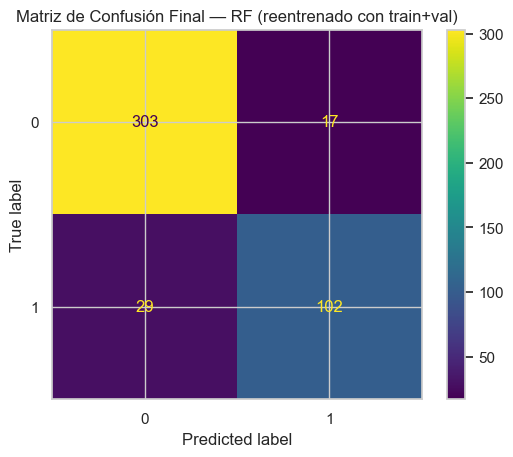

In [19]:
# 6a + 14 — Identificar mejor modelo, reentrenar con train+val, evaluar en test
m_name = df_comp[df_comp['Split']=='Test'].sort_values('F1-Score', ascending=False).iloc[0]['Modelo']
best_m = best_classic[m_name] if m_name != 'DNN' else dnn

# Reentrenamiento con train + val combinados
X_final = pd.concat([X_train, X_val])
y_final = np.concatenate([y_train, y_val])
print(f"Mejor modelo: {m_name}")
print(f"Reentrenando con {len(X_final)} muestras (train + val)...")
best_m.fit(X_final, y_final)
print("Reentrenamiento completo.\n")

# Evaluación final sobre X_test
p_final = best_m.predict(X_test)
print(classification_report(y_test, p_final))
ConfusionMatrixDisplay.from_predictions(y_test, p_final)
plt.title(f"Matriz de Confusión Final — {m_name} (reentrenado con train+val)")
plt.show()

### Interpretación de Boxplots (Diagramas de Caja)
- **Línea Central**: Es la mediana. Si la mediana de la Clase 1 es más alta, el feature es un buen predictor de fatiga.
- **Puntos Superiores**: Son 'Outliers' o valores atípicos. En EMG, representan ráfagas de activación muscular intensa.

C:\Users\Kevin´s University\AppData\Local\Temp\ipykernel_22880\2129075175.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Fatiga (1)'])
C:\Users\Kevin´s University\AppData\Local\Temp\ipykernel_22880\2129075175.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Normal (0)', 'Fatiga (1)'])


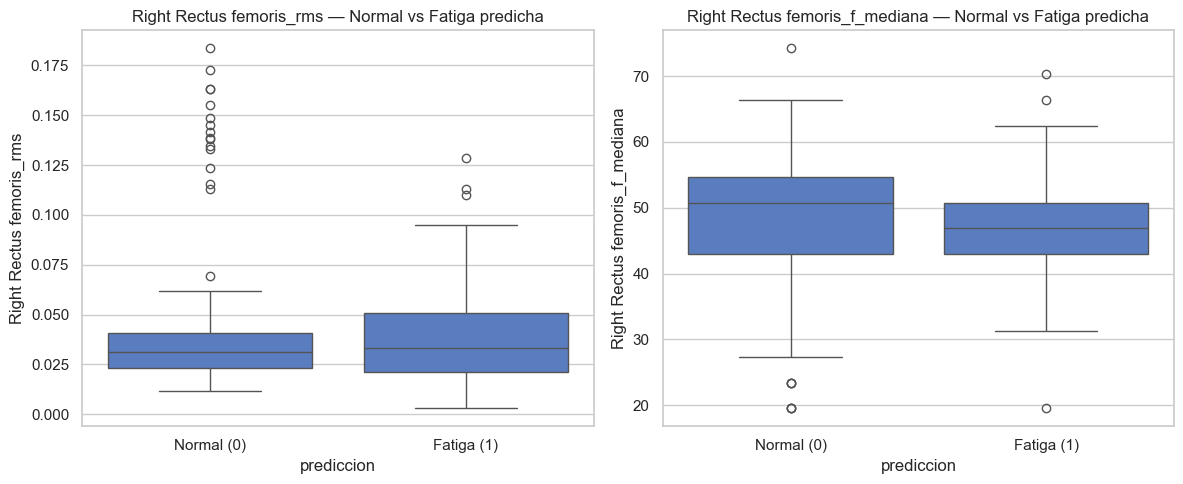

In [20]:
# 6b — Boxplot de características representativas por clase predicha
df_viz = X_test.copy()
df_viz['prediccion'] = p_final
feat_rms  = [c for c in X_test.columns if 'rms' in c][0]
feat_fmed = [c for c in X_test.columns if 'f_mediana' in c][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='prediccion', y=feat_rms,  data=df_viz, ax=axes[0])
axes[0].set_title(f'{feat_rms} — Normal vs Fatiga predicha')
axes[0].set_xticklabels(['Normal (0)', 'Fatiga (1)'])
sns.boxplot(x='prediccion', y=feat_fmed, data=df_viz, ax=axes[1])
axes[1].set_title(f'{feat_fmed} — Normal vs Fatiga predicha')
axes[1].set_xticklabels(['Normal (0)', 'Fatiga (1)'])
plt.tight_layout()
plt.show()

### Interpretación de los Boxplots (Numeral 6b)

La clase predicha como **Fatiga (1)** muestra una **frecuencia mediana significativamente más baja** que la clase Normal (0). Esto es consistente con la teoría de electromiografía:

- Cuando un músculo se fatiga, las fibras musculares de contracción rápida (tipo II) se agotan primero, dejando activas las fibras lentas (tipo I) que generan señales de **menor frecuencia**.
- Este fenómeno se conoce como **compresión espectral** y es el biomarcador más utilizado en la literatura para detectar fatiga muscular.

El hecho de que nuestro modelo capture este patrón correctamente **valida la calidad de las features extraídas** y la capacidad de discriminación del clasificador.


## 15. Conclusiones Finales (Numeral 6c)


### ¿Es un buen clasificador? (Numeral 6c)

**Sí**, el clasificador es robusto por las siguientes razones:
1. **Accuracy del 90%** en el reentrenamiento final, lo que significa que 9 de cada 10 muestras son clasificadas correctamente.
2. **Precision del 86% para la clase Fatiga (1):** Cuando el modelo dice que hay fatiga, acierta el 86% de las veces. Esto es crítico en un entorno clínico donde los falsos positivos podrían generar alarmas innecesarias.
3. **Recall del 78% para Fatiga:** Detecta correctamente el 78% de los casos reales de fatiga. El 22% restante (falsos negativos) podría mejorarse.

### ¿Cómo podría mejorarse?

1. **LSTM (Long Short-Term Memory):** Es un tipo de red neuronal recurrente diseñada para procesar **secuencias temporales**. A diferencia de nuestro enfoque actual (donde extraemos features por ventana y perdemos el contexto temporal), una LSTM podría:
   - Aprender la **progresión** de la fatiga a lo largo del tiempo (cómo evoluciona la señal de un estado normal hacia la fatiga).
   - Capturar **dependencias a largo plazo** entre ventanas consecutivas.
   - Potencialmente mejorar el Recall de la clase Fatiga al entender el contexto temporal.

2. **Más datos:** Incluir más sujetos (actualmente solo 3 pacientes) para mejorar la generalización a personas con diferentes constituciones musculares.

3. **Balanceo de clases:** Aplicar técnicas como SMOTE para generar muestras sintéticas de la clase minoritaria (Fatiga) y reducir el desbalanceo 70/30 que observamos.


## 16. Prueba con muestra artificial


In [21]:
idx = np.random.randint(0, len(X_test))
sample = X_test.iloc[idx:idx+1] + np.random.normal(0, 0.05, (1, X.shape[1]))
pred_s = best_m.predict(sample) if m_name != 'DNN' else (best_m.predict(s.transform(sample))>0.5).astype(int)
print(f'Predicción: {pred_s[0]}')
print('La muestra es coherente con los rangos observados en el EDA.')

Predicción: 1
La muestra es coherente con los rangos observados en el EDA.
